
📊 ATE Estimate: 0.0338
📏 95% CI: (-0.1039, 0.1715)
📉 SE: 0.0702
🧪 P-value: 0.6307


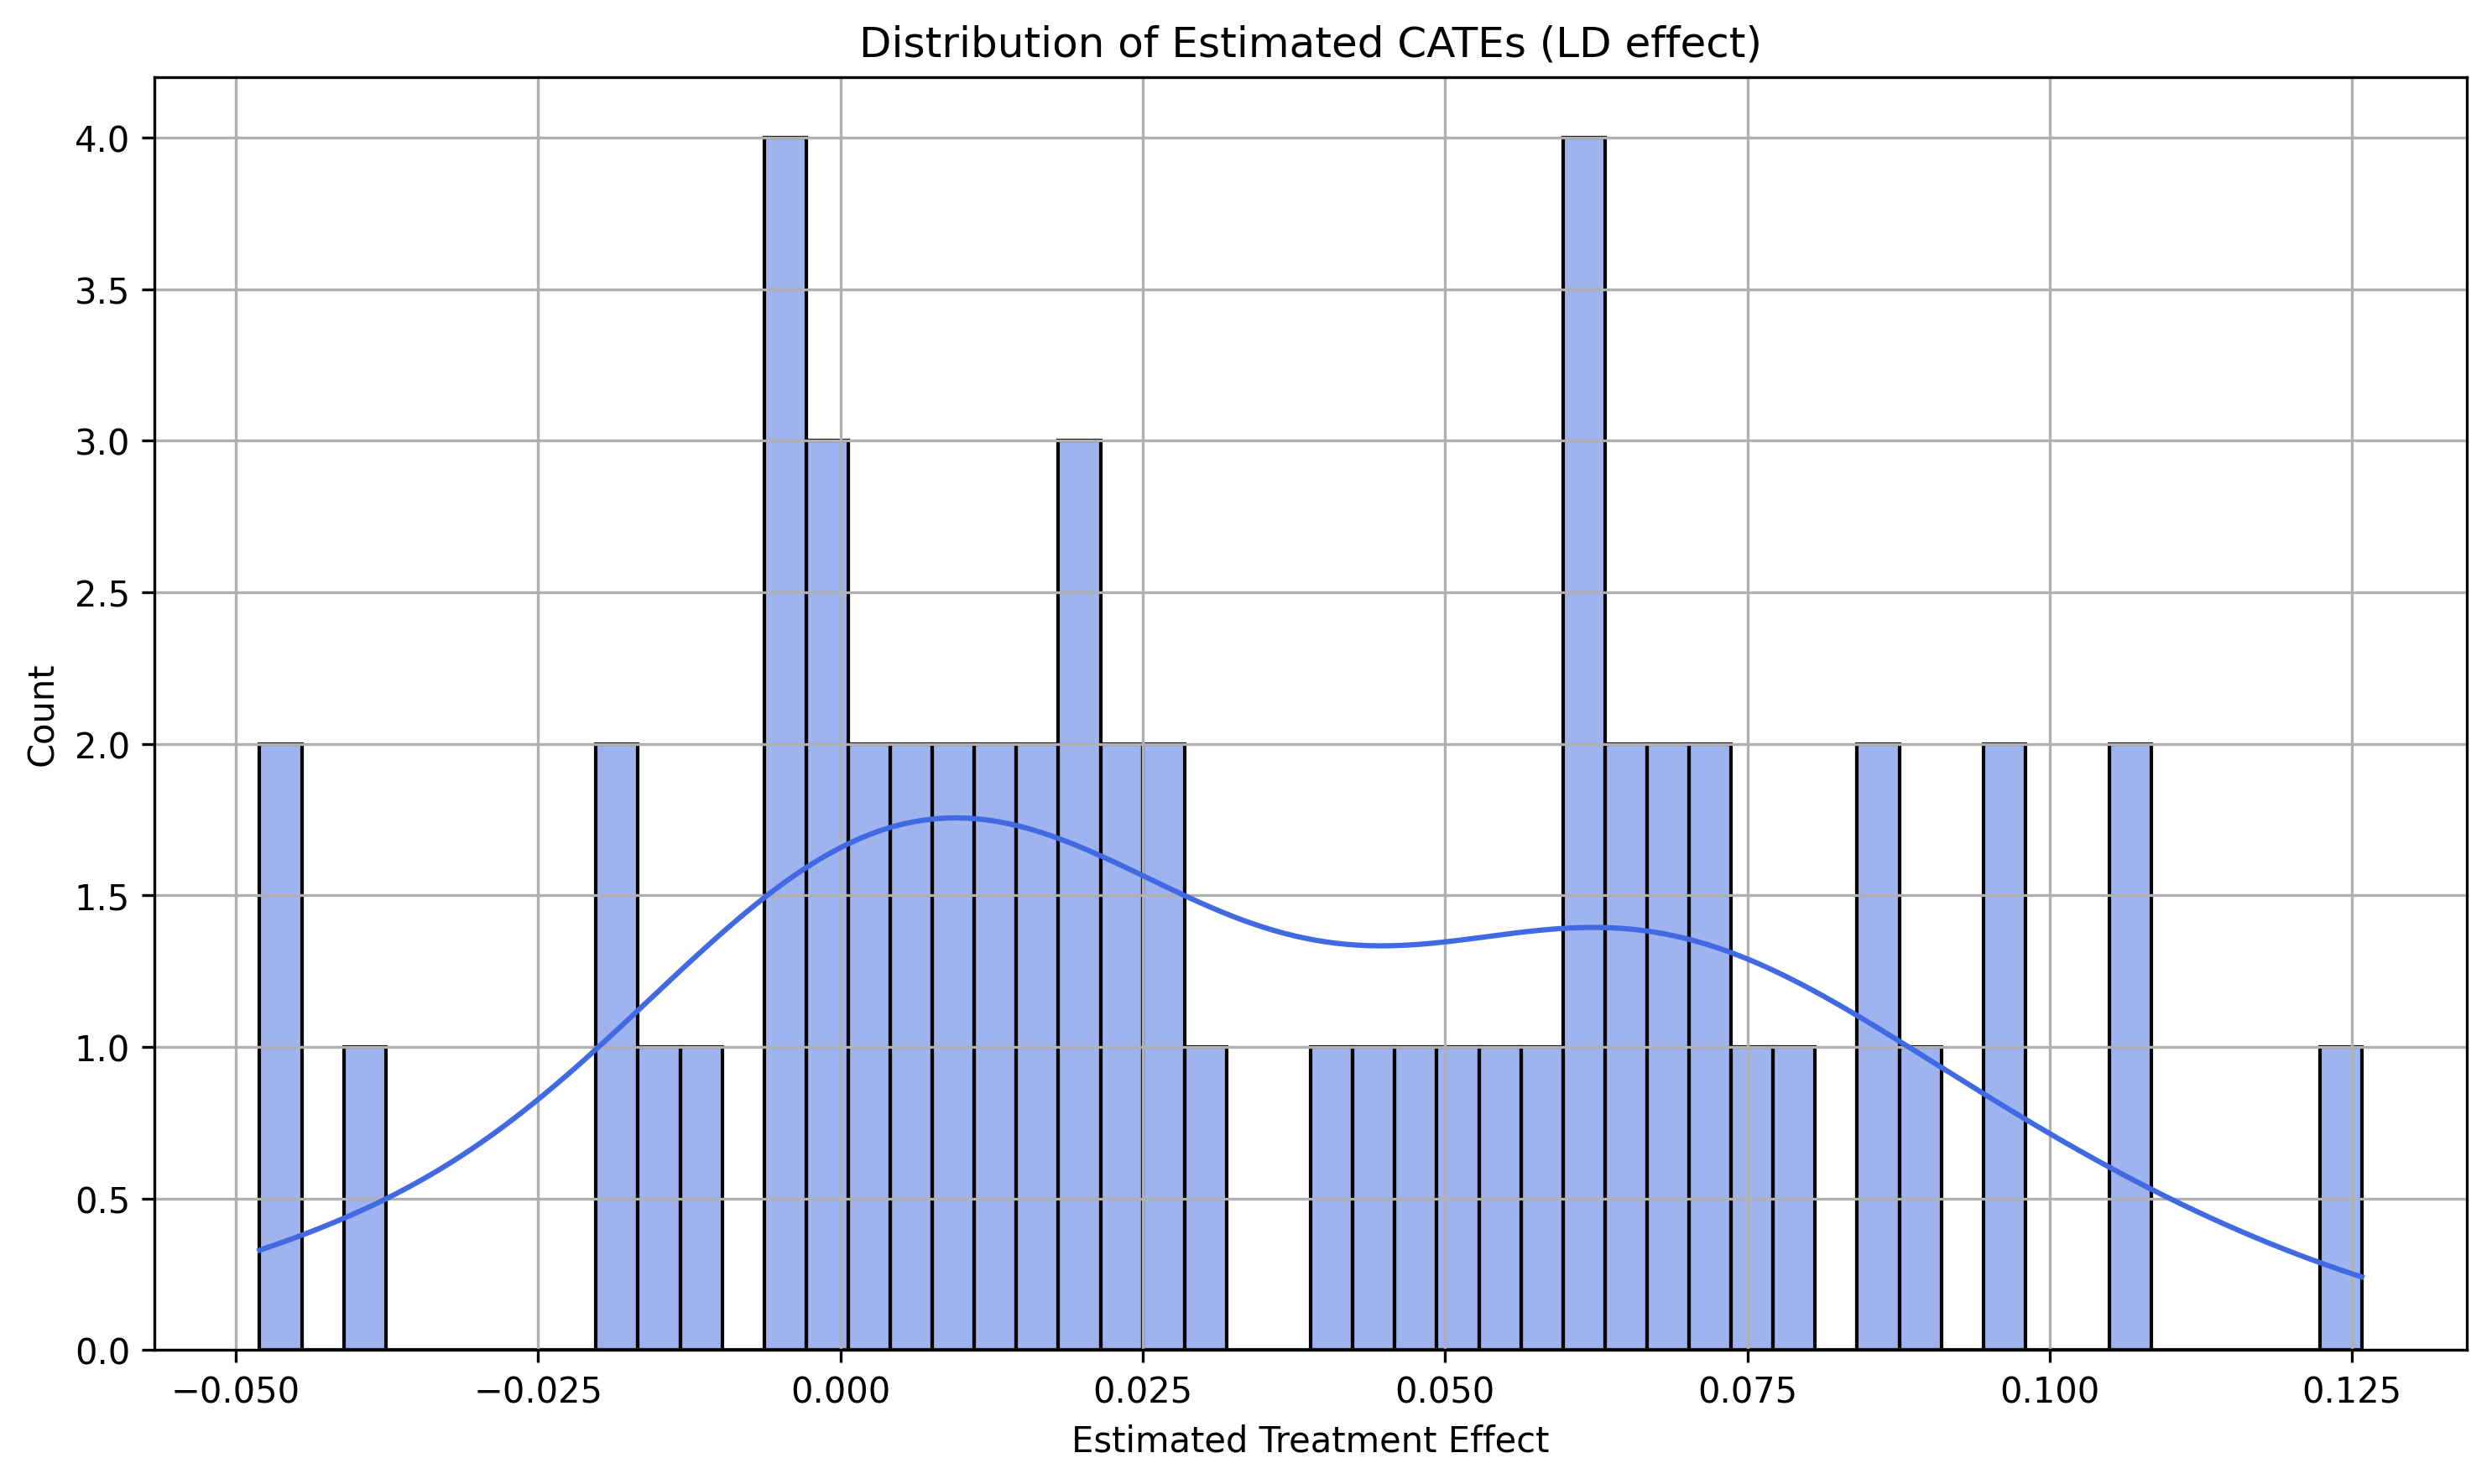

In [8]:
import os
from modules.preprocess import load_and_clean_data, prepare_variables 
from modules.dml import train_causal_forest, evaluate_ate, plot_cates, export_cate_results, learn_policy, learn_policy_forest, save_model, get_feature_importances
from sklearn.model_selection import train_test_split

df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
Outcome = 'shunt_180'
X, Y, T, feature_names = prepare_variables(df, Outcome)

X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(X, T, Y, test_size=0.2, random_state=42)

cf_model = train_causal_forest(X_train, Y_train, T_train)
results = evaluate_ate(cf_model, X_test)

print(f"\n📊 ATE Estimate: {results['ate']:.4f}")
print(f"📏 95% CI: ({results['ci'][0]:.4f}, {results['ci'][1]:.4f})")
print(f"📉 SE: {results['se']:.4f}")
print(f"🧪 P-value: {results['pval']:.4f}")

cates = cf_model.effect(X_test)
plot_cates(cates)



📊 ATE Estimate: 0.0552
📏 95% CI: (-0.0788, 0.1893)
📉 SE: 0.0684
🧪 P-value: 0.4193


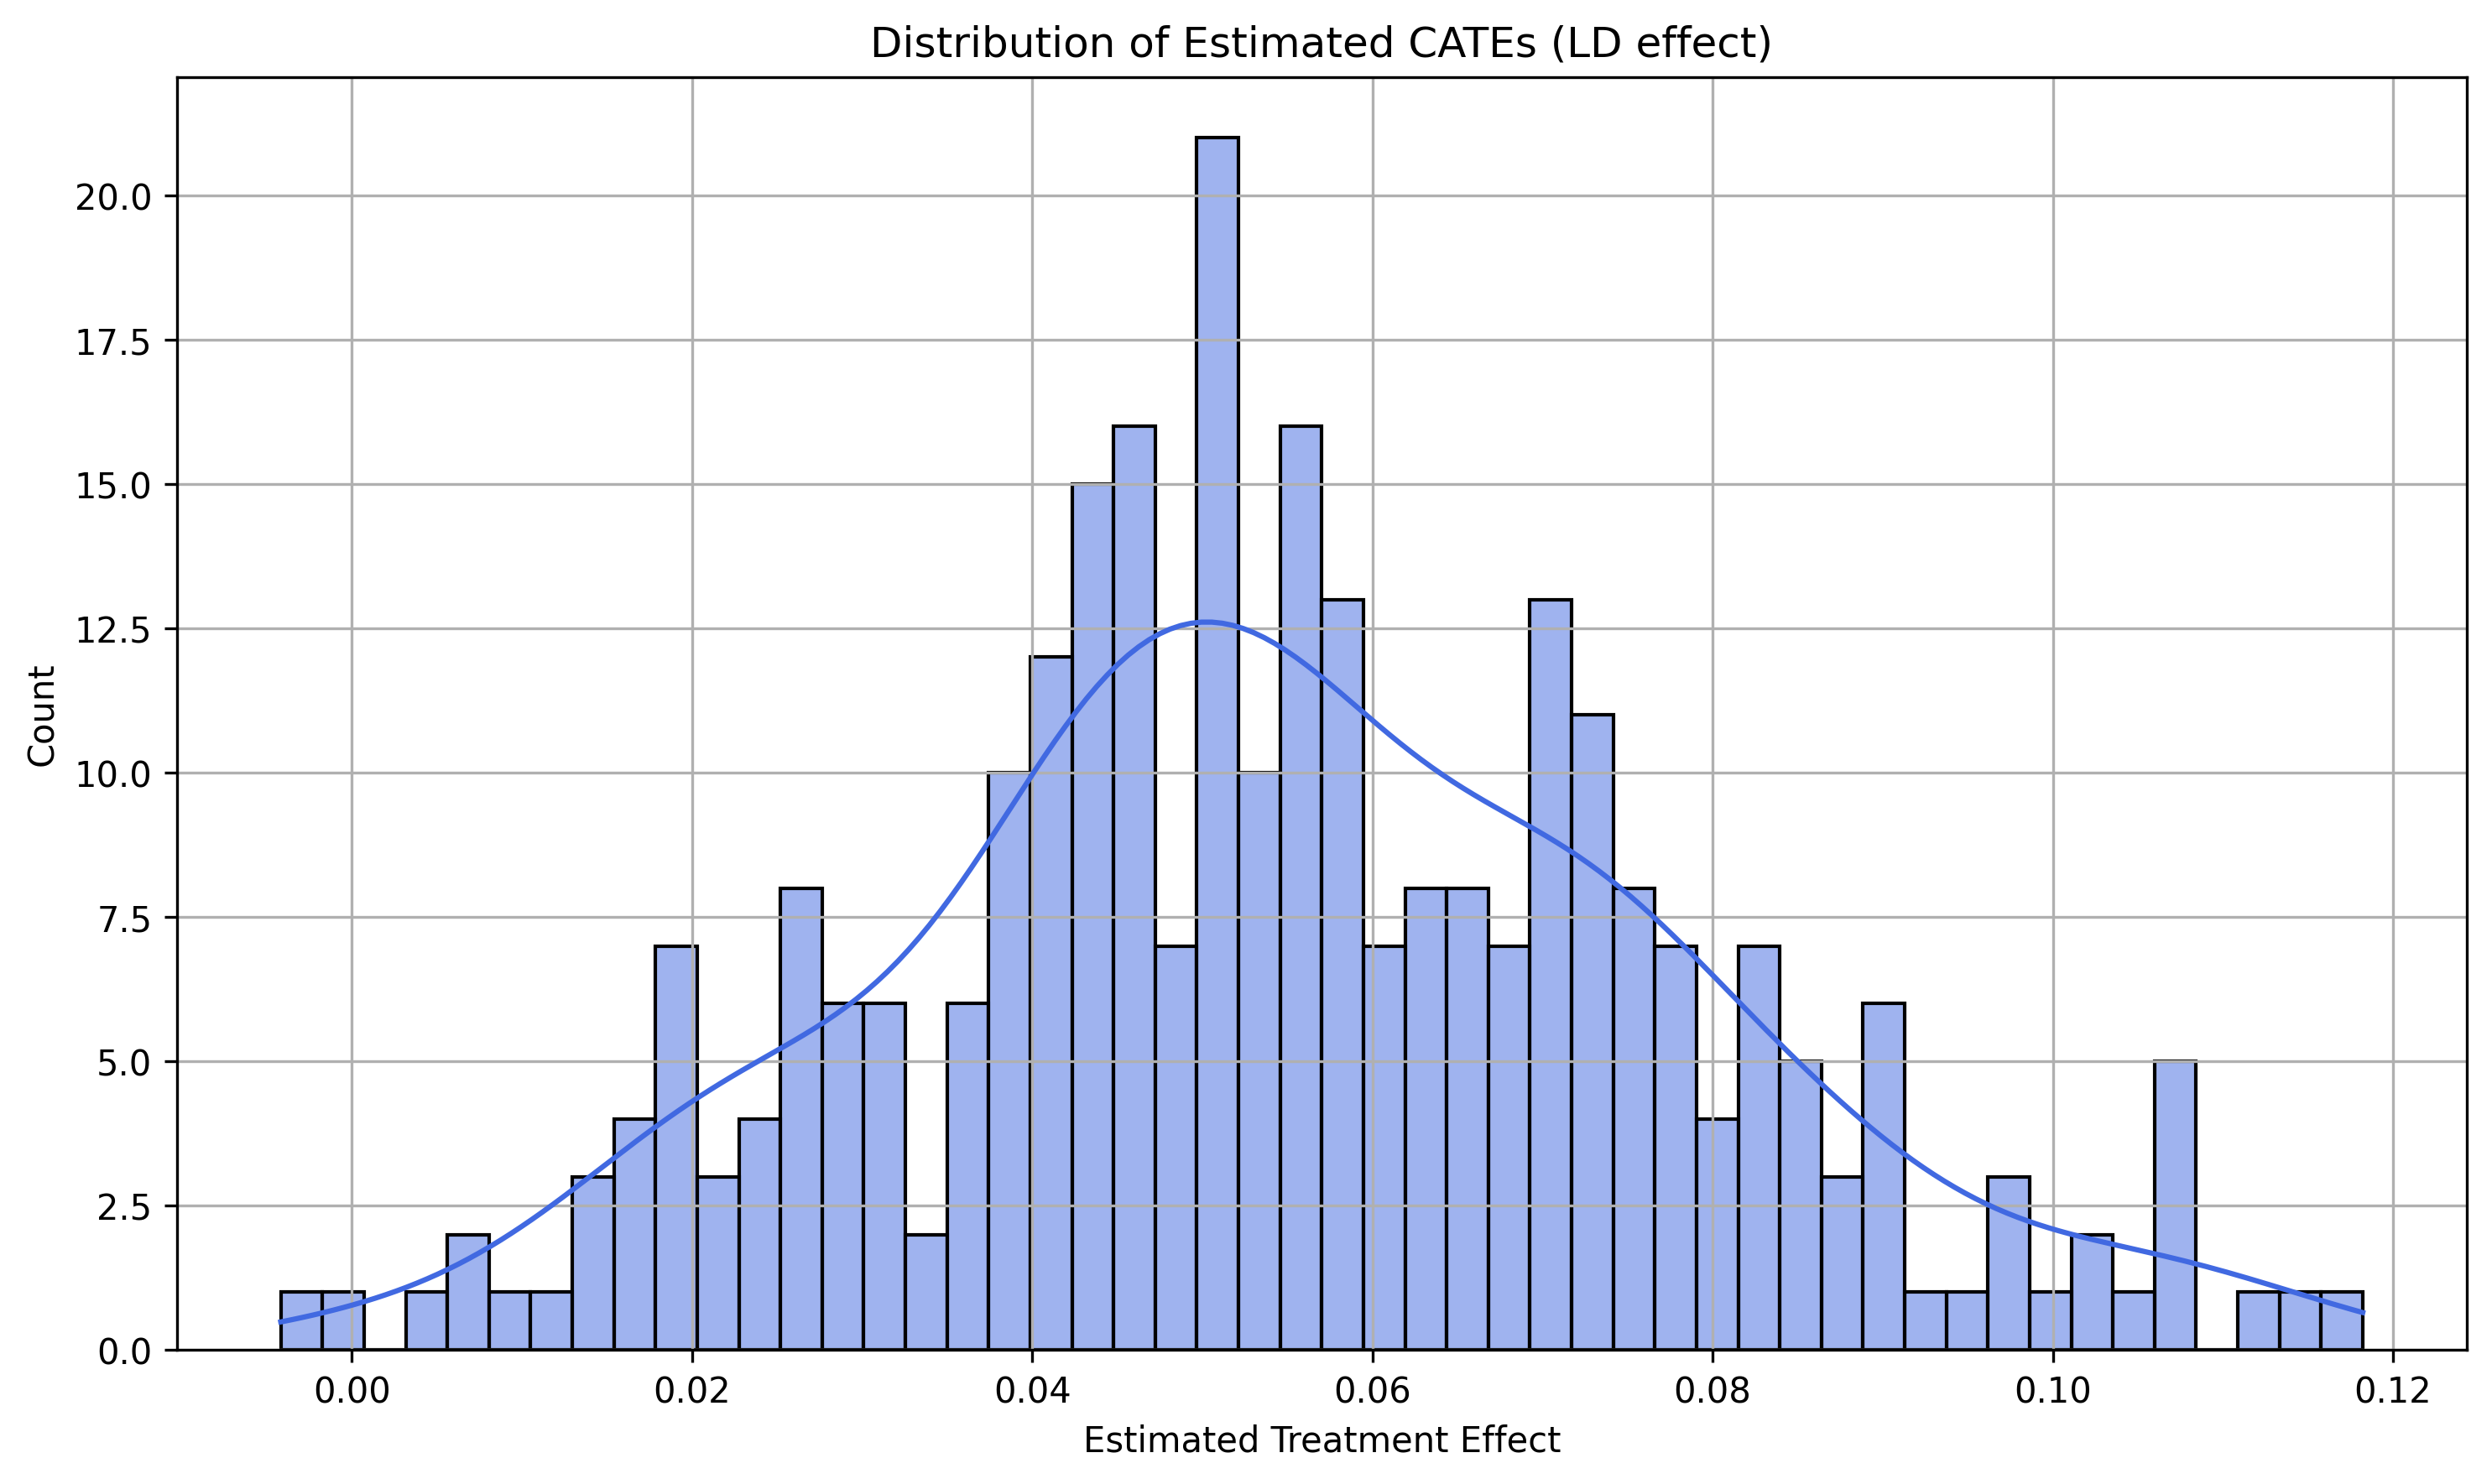

Exported all 287 patients' CATEs to cate_results\cate_results_shunt_180.csv
Model saved to models/cf_model_shunt_180.joblib


In [9]:
df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
X, Y, T, feature_names = prepare_variables(df, Outcome)

cf_model = train_causal_forest(X, Y, T)
results = evaluate_ate(cf_model, X)

print(f"\n📊 ATE Estimate: {results['ate']:.4f}")
print(f"📏 95% CI: ({results['ci'][0]:.4f}, {results['ci'][1]:.4f})")
print(f"📉 SE: {results['se']:.4f}")
print(f"🧪 P-value: {results['pval']:.4f}")

cates = cf_model.effect(X)
plot_cates(cates)
export_cate_results(X, cates, Y, T, feature_names, outcome_name=Outcome)
save_model(cf_model, path=f"models/cf_model_{Outcome}.joblib")

In [10]:
get_feature_importances(cf_model, feature_names)


Feature Importances (CausalForestDML):
bmi: 0.1127
csf_mean: 0.1051
rr_syst_mean: 0.0998
icp_7am_mean: 0.0940
icp_high_mean: 0.0894
hb_mean: 0.0789
aneurysm_size: 0.0707
age: 0.0669
balance_mean: 0.0652
rr_dia_mean: 0.0543
rr_map_mean: 0.0354
wfns: 0.0327
ct_ich: 0.0160
hh: 0.0140
aneurysm_trt: 0.0127
sex: 0.0094
ct_modfisher: 0.0092
ct_ivh: 0.0091
mg: 0.0088
aphasia_adm: 0.0048
paresis_adm: 0.0046
aneurysm_no: 0.0034
aneurysm_circulation: 0.0019
sedation_adm: 0.0006
statin: 0.0005
nimodipine: 0.0000
mrs_adm: 0.0000


bmi                     0.112686
csf_mean                0.105077
rr_syst_mean            0.099799
icp_7am_mean            0.093980
icp_high_mean           0.089430
hb_mean                 0.078858
aneurysm_size           0.070687
age                     0.066874
balance_mean            0.065190
rr_dia_mean             0.054312
rr_map_mean             0.035369
wfns                    0.032723
ct_ich                  0.015962
hh                      0.013988
aneurysm_trt            0.012681
sex                     0.009416
ct_modfisher            0.009198
ct_ivh                  0.009146
mg                      0.008768
aphasia_adm             0.004772
paresis_adm             0.004634
aneurysm_no             0.003400
aneurysm_circulation    0.001931
sedation_adm            0.000616
statin                  0.000501
nimodipine              0.000000
mrs_adm                 0.000000
dtype: float64

c:\Users\shrin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 129504 (\N{BRAIN}) missing from current font.



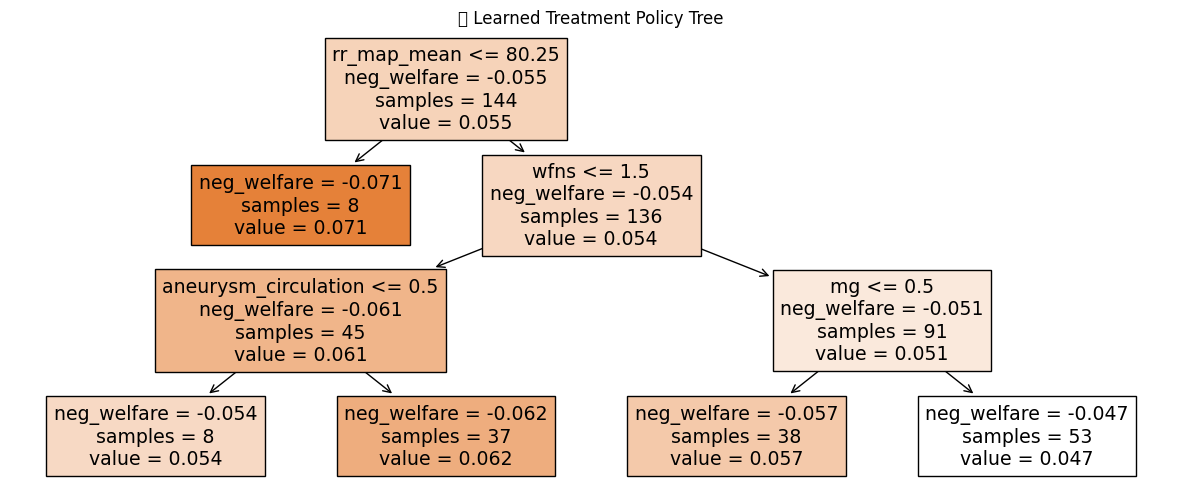

📋 Policy recommendations:
 [0 0 0 0 0 0 0 0 0 0]


In [11]:
policy_tree = learn_policy(cf_model, X)
import matplotlib.pyplot as plt

# Visualize
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 6))
plot_tree(policy_tree, feature_names=feature_names, filled=True)
plt.title("🧠 Learned Treatment Policy Tree")
plt.show()

# Binary treatment recommendations
policy_recs = policy_tree.predict(X)
print("📋 Policy recommendations:\n", policy_recs[:10])



🔬 Subgroup CATEs: aneurysm_trt
Group 1 = clipping → Mean CATE: 0.0539
Group 2 = coiling → Mean CATE: 0.0565
ΔCATE (clipping - coiling) = -0.0027
🧪 P-value: 0.3248


c:\Precision_Medicine_EARLYDRAIN_DML\modules\analysis.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




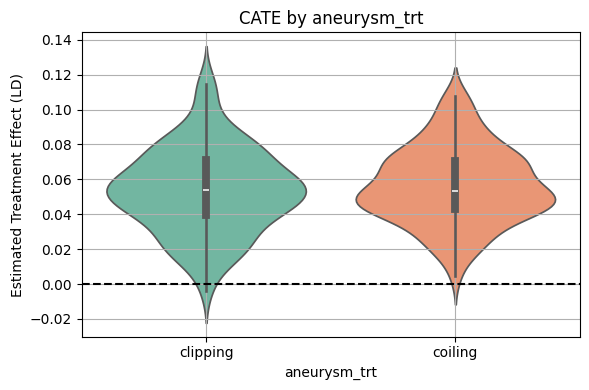


🔬 Subgroup CATEs: aneurysm_circulation
Group 1 = anterior → Mean CATE: 0.0558
Group 2 = posterior → Mean CATE: 0.0519
ΔCATE (anterior - posterior) = 0.0040
🧪 P-value: 0.2424


c:\Precision_Medicine_EARLYDRAIN_DML\modules\analysis.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




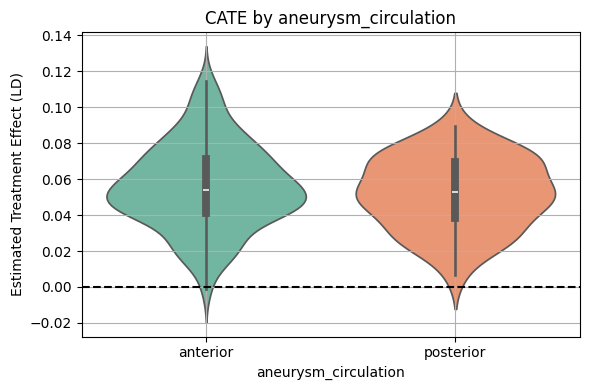


🔬 Subgroup CATEs: paresis_adm
Group 1 = yes → Mean CATE: 0.0488
Group 2 = no → Mean CATE: 0.0580
ΔCATE (yes - no) = -0.0092
🧪 P-value: 0.0009


c:\Precision_Medicine_EARLYDRAIN_DML\modules\analysis.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




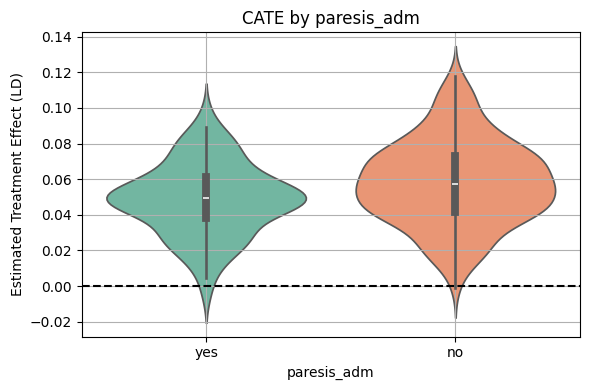


🔬 Subgroup CATEs: aphasia_adm
Group 1 = yes → Mean CATE: 0.0491
Group 2 = no → Mean CATE: 0.0583
ΔCATE (yes - no) = -0.0091
🧪 P-value: 0.0007


c:\Precision_Medicine_EARLYDRAIN_DML\modules\analysis.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




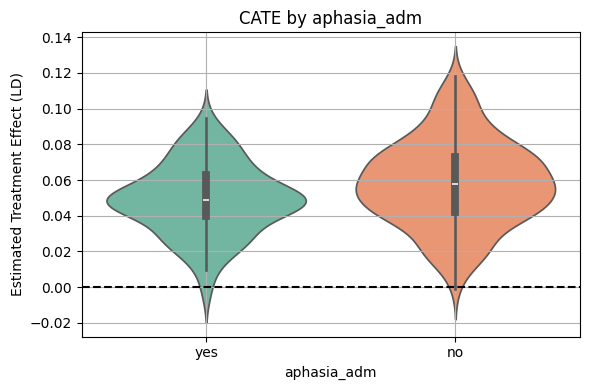

c:\Precision_Medicine_EARLYDRAIN_DML\modules\analysis.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.





🔬 Subgroup CATEs: nimodipine
Group 1 = yes → Mean CATE: 0.0555
Group 2 = no → Mean CATE: 0.0293
ΔCATE (yes - no) = 0.0262
🧪 P-value: 0.2771


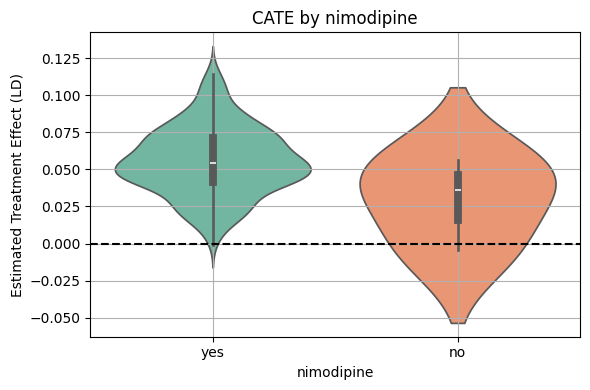


🔬 Subgroup CATEs: ct_ivh
Group 1 = no → Mean CATE: 0.0598
Group 2 = yes → Mean CATE: 0.0523
ΔCATE (no - yes) = 0.0075
🧪 P-value: 0.0076


c:\Precision_Medicine_EARLYDRAIN_DML\modules\analysis.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




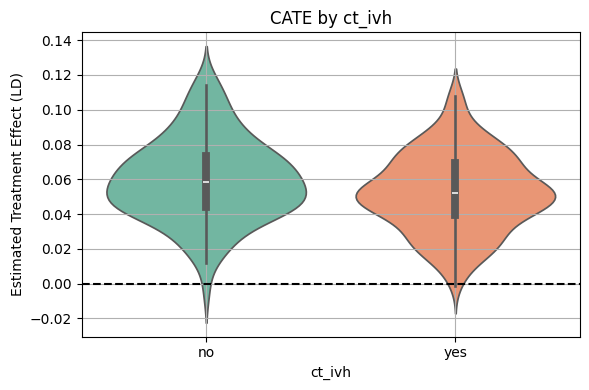


🔬 Subgroup CATEs: ct_ich
Group 1 = no → Mean CATE: 0.0556
Group 2 = yes → Mean CATE: 0.0546
ΔCATE (no - yes) = 0.0011
🧪 P-value: 0.6976


c:\Precision_Medicine_EARLYDRAIN_DML\modules\analysis.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




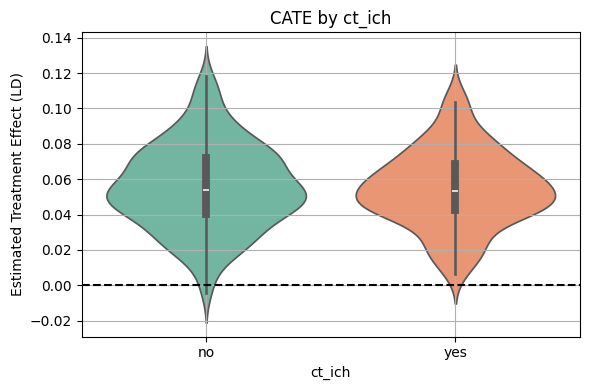

In [12]:
from modules.analysis import analyze_binary_subgroup_cates, plot_cate_vs_feature, analyze_ordinal_features, run_doubleml_analysis
import pandas as pd

binary_features = ['aneurysm_trt', 'aneurysm_circulation', 'paresis_adm', 'aphasia_adm', 'nimodipine', 'ct_ivh', 'ct_ich']
cate_df = pd.DataFrame(X, columns=feature_names)
cate_df['treatment_effect'] = cates
reverse_maps = {
    'aneurysm_trt': {1: 'coiling', 0: 'clipping'},
    'aneurysm_circulation': {1: 'anterior', 0: 'posterior'},
    'paresis_adm': {1: 'yes', 0: 'no'},
    'aphasia_adm': {1: 'yes', 0: 'no'},
    'nimodipine': {1: 'yes', 0: 'no'},
    'ct_ivh': {1: 'yes', 0: 'no'},
    'ct_ich': {1: 'yes', 0: 'no'},
    'statin': {1: 'yes', 0: 'no'},
    'mg': {1: 'yes', 0: 'no'},
    'infarct_trt': {1: 'yes', 0: 'no'},
}

analyze_binary_subgroup_cates(cate_df, df, cates, binary_features, reverse_maps)


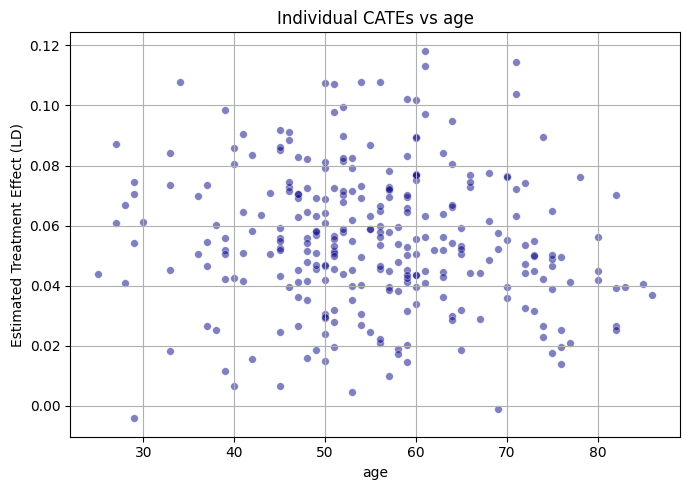

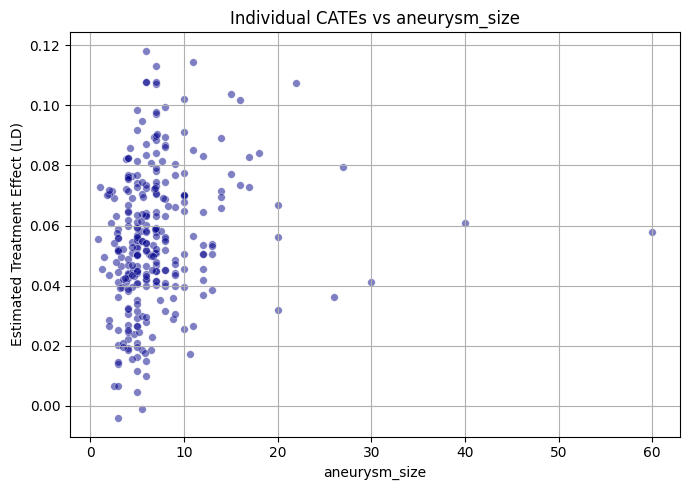

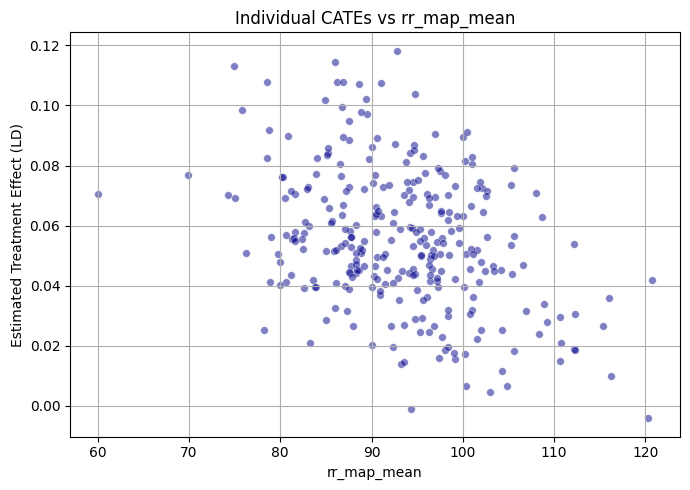

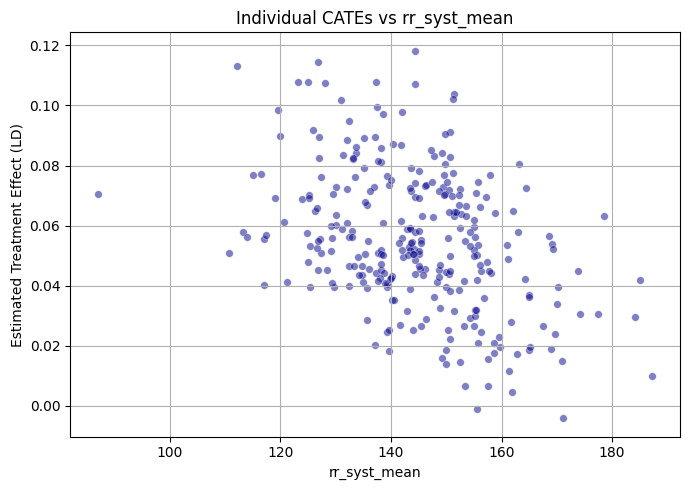

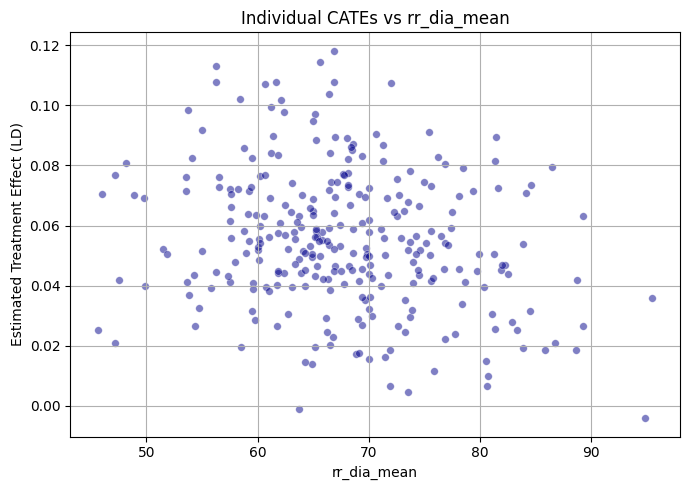

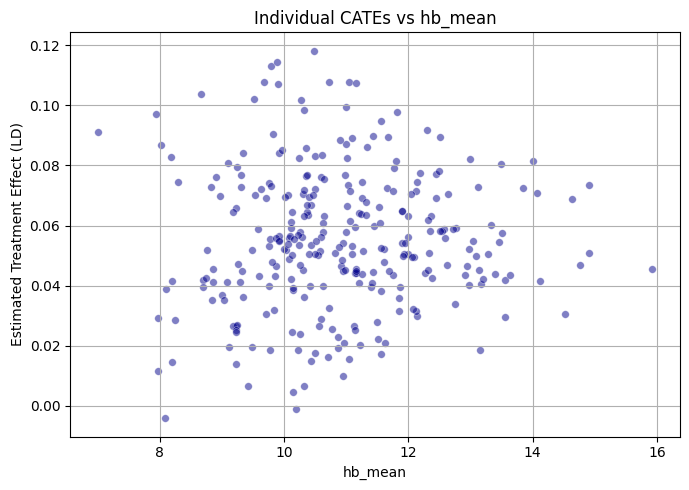

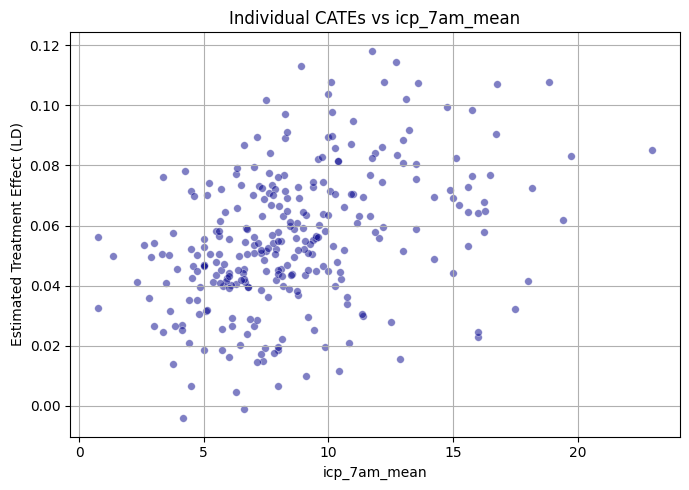

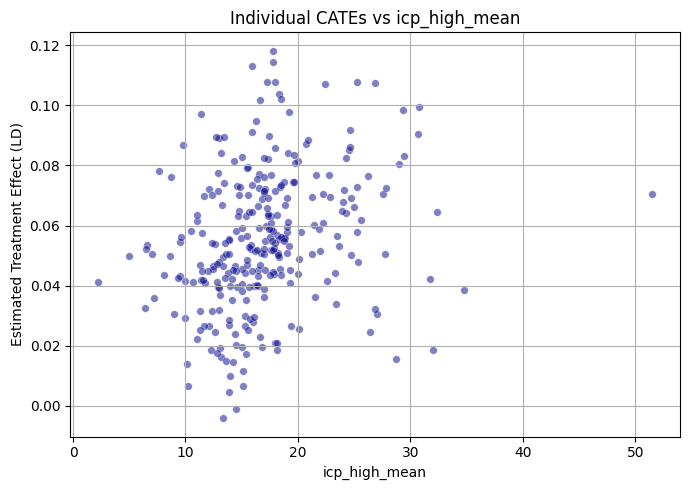

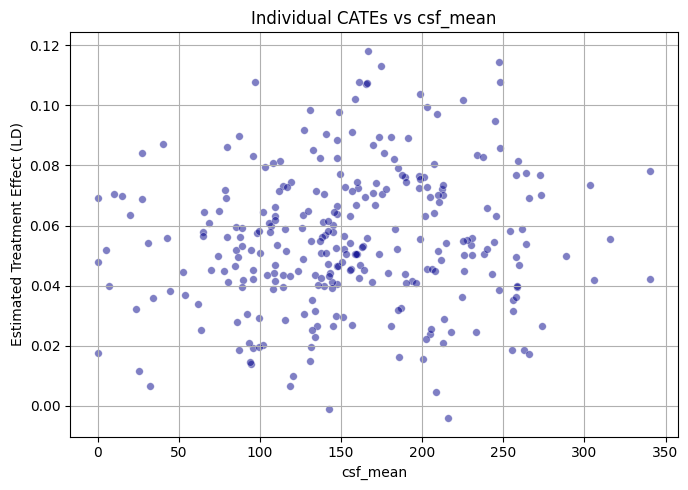

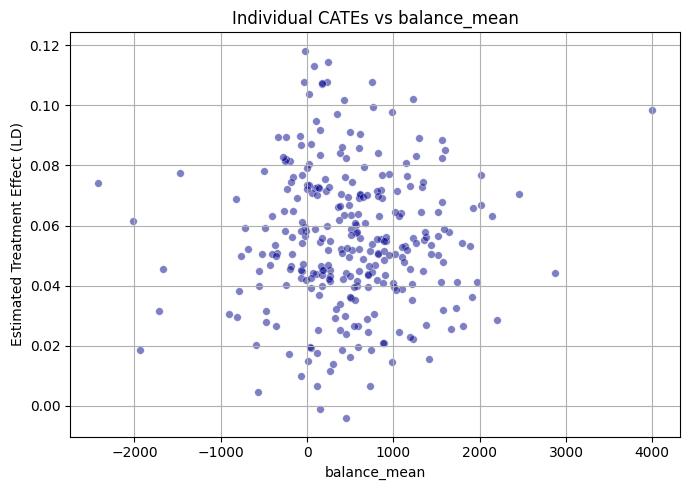

In [13]:
plot_cate_vs_feature(cate_df, 'age')
plot_cate_vs_feature(cate_df, 'aneurysm_size')
plot_cate_vs_feature(cate_df, 'rr_map_mean')
plot_cate_vs_feature(cate_df, 'rr_syst_mean')
plot_cate_vs_feature(cate_df, 'rr_dia_mean')
plot_cate_vs_feature(cate_df, 'hb_mean')
plot_cate_vs_feature(cate_df, 'icp_7am_mean')
plot_cate_vs_feature(cate_df, 'icp_high_mean')
plot_cate_vs_feature(cate_df, 'csf_mean')
plot_cate_vs_feature(cate_df, 'balance_mean')


In [ ]:
dml_model = run_doubleml_analysis(X, Y, T, feature_names)
